<a href="https://colab.research.google.com/github/Prathama-1/Prosperity-4---Solo42/blob/main/Round5_dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats, signal
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Monte Carlo + statistical helpers
from itertools import combinations

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9,
                     'axes.titlesize': 10, 'axes.labelsize': 9})



In [2]:
# ─── CELL 2: Load Data ───────────────────────────────────────
# Upload prices_round_5_day_{2,3,4}.csv and trades_round_5_day_{2,3,4}.csv to Colab
# then run this cell.

import os

def load_prices():
    frames = []
    for day in [2, 3, 4]:
        fname = f"prices_round_5_day_{day}.csv"
        if not os.path.exists(fname):
            raise FileNotFoundError(f"Missing {fname} — upload it to Colab first")
        df = pd.read_csv(fname, sep=';')
        frames.append(df)
    prices = pd.concat(frames, ignore_index=True)
    prices['global_ts'] = (prices['day'] - 2) * 1_000_000 + prices['timestamp']
    prices['spread']    = prices['ask_price_1'] - prices['bid_price_1']
    prices['mid_price'] = prices['mid_price'].astype(float)
    return prices

def load_trades():
    frames = []
    for day in [2, 3, 4]:
        fname = f"trades_round_5_day_{day}.csv"
        if not os.path.exists(fname):
            raise FileNotFoundError(f"Missing {fname} — upload it to Colab first")
        df = pd.read_csv(fname, sep=';')
        frames.append(df)
    trades = pd.concat(frames, ignore_index=True)
    return trades

prices = load_prices()
trades = load_trades()

ALL_PRODUCTS = sorted(prices['product'].unique())
GROUPS = {
    'GALAXY_SOUNDS':  [p for p in ALL_PRODUCTS if p.startswith('GALAXY')],
    'SLEEP_POD':      [p for p in ALL_PRODUCTS if p.startswith('SLEEP')],
    'MICROCHIP':      [p for p in ALL_PRODUCTS if p.startswith('MICROCHIP')],
    'PEBBLES':        [p for p in ALL_PRODUCTS if p.startswith('PEBBLES')],
    'ROBOT':          [p for p in ALL_PRODUCTS if p.startswith('ROBOT')],
    'UV_VISOR':       [p for p in ALL_PRODUCTS if p.startswith('UV')],
    'TRANSLATOR':     [p for p in ALL_PRODUCTS if p.startswith('TRANS')],
    'PANEL':          [p for p in ALL_PRODUCTS if p.startswith('PANEL')],
    'OXYGEN_SHAKE':   [p for p in ALL_PRODUCTS if p.startswith('OXYGEN')],
    'SNACKPACK':      [p for p in ALL_PRODUCTS if p.startswith('SNACK')],
}

print(f"✅ Loaded {len(prices):,} price rows, {len(trades):,} trade rows")
print(f"   Products: {len(ALL_PRODUCTS)} | Days: {sorted(prices['day'].unique())}")

✅ Loaded 210,150 price rows, 35,385 trade rows
   Products: 50 | Days: [np.int64(2), np.int64(3), np.int64(4)]


In [3]:
# ─── CELL 3: Per-Product Summary Statistics ──────────────────
def compute_stats(prices):
    records = []
    for prod in ALL_PRODUCTS:
        sub = prices[prices['product'] == prod].sort_values('global_ts')
        p   = sub['mid_price'].values
        ret = np.diff(np.log(p))
        spread = sub['spread'].values

        # Basic
        mean_p  = p.mean()
        vol_pct = p.std() / mean_p * 100
        trend   = (p[-1] - p[0]) / p[0] * 100  # total % move days 2-4

        # Returns
        ac1     = pd.Series(ret).autocorr(1)
        sharpe  = ret.mean() / (ret.std() + 1e-10) * np.sqrt(10_000)

        # Spread
        sp_mean = spread.mean()
        sp_pct  = sp_mean / mean_p * 100

        # Regime: trending or mean-reverting (Hurst exponent approx)
        lags  = range(2, 20)
        tau   = [np.std(np.subtract(p[lag:], p[:-lag])) for lag in lags]
        hurst = np.polyfit(np.log(lags), np.log(tau), 1)[0]

        records.append({
            'product': prod,
            'group': next((g for g, pl in GROUPS.items() if prod in pl), 'OTHER'),
            'mean_price': mean_p,
            'vol_pct': vol_pct,
            'total_trend_pct': trend,
            'ac1': ac1,
            'hurst': hurst,
            'sharpe_like': sharpe,
            'spread_mean': sp_mean,
            'spread_pct': sp_pct,
            'price_min': p.min(),
            'price_max': p.max(),
        })

    return pd.DataFrame(records).set_index('product')

stats_df = compute_stats(prices)

# ---- Print ranked summary ----
print("\n{'='*70}")
print("PRODUCT SUMMARY — sorted by |total trend| (best momentum candidates first)")
print('='*70)
display_cols = ['group','mean_price','vol_pct','total_trend_pct','hurst','ac1','spread_pct']
print(stats_df[display_cols].sort_values('total_trend_pct').to_string())


{'='*70}
PRODUCT SUMMARY — sorted by |total trend| (best momentum candidates first)
                                       group    mean_price    vol_pct  total_trend_pct     hurst       ac1  spread_pct
product                                                                                                               
PEBBLES_XS                           PEBBLES   8342.466571  16.609821          -34.935  0.505464  0.011880    0.130364
MICROCHIP_OVAL                     MICROCHIP   8749.483940  13.129343          -32.625  0.481838 -0.016503    0.090265
UV_VISOR_AMBER                      UV_VISOR   8321.422117  14.291905          -31.030  0.485624  0.003828    0.130060
MICROCHIP_RECTANGLE                MICROCHIP   8984.971575  10.349920          -21.255  0.492471 -0.006217    0.089914
ROBOT_IRONING                          ROBOT   9118.201999   9.926617          -19.700  0.480030 -0.028599    0.077696
PEBBLES_S                            PEBBLES   9324.757020   8.107220          -19

In [4]:
# ─── CELL 4: Regime Classification ───────────────────────────
# Hurst > 0.5 → trending / persistent
# Hurst < 0.5 → mean-reverting
# Classify each product

def classify(row):
    if abs(row['total_trend_pct']) > 15 and row['hurst'] > 0.45:
        return 'STRONG_TREND'
    elif abs(row['total_trend_pct']) > 5 and row['hurst'] > 0.45:
        return 'MILD_TREND'
    elif row['hurst'] < 0.45 and row['vol_pct'] < 3:
        return 'MEAN_REV_TIGHT'
    elif row['hurst'] < 0.48:
        return 'MEAN_REV'
    else:
        return 'RANDOM_WALK'

stats_df['regime'] = stats_df.apply(classify, axis=1)
print("\n=== REGIME CLASSIFICATION ===")
print(stats_df.groupby('regime')['group'].value_counts().to_string())
print()
for regime in stats_df['regime'].unique():
    prods = stats_df[stats_df['regime']==regime].index.tolist()
    print(f"\n{regime}:")
    for p in prods:
        r = stats_df.loc[p]
        print(f"  {p:45s}  trend={r['total_trend_pct']:+7.2f}%  hurst={r['hurst']:.3f}  vol={r['vol_pct']:.2f}%")



=== REGIME CLASSIFICATION ===
regime        group        
MILD_TREND    PANEL            4
              TRANSLATOR       3
              GALAXY_SOUNDS    2
              MICROCHIP        2
              OXYGEN_SHAKE     2
              PEBBLES          2
              ROBOT            2
              SNACKPACK        2
              UV_VISOR         2
RANDOM_WALK   SNACKPACK        3
              GALAXY_SOUNDS    2
              OXYGEN_SHAKE     2
              SLEEP_POD        2
              TRANSLATOR       2
              PANEL            1
              ROBOT            1
STRONG_TREND  MICROCHIP        3
              PEBBLES          3
              SLEEP_POD        3
              UV_VISOR         3
              ROBOT            2
              GALAXY_SOUNDS    1
              OXYGEN_SHAKE     1


STRONG_TREND:
  GALAXY_SOUNDS_BLACK_HOLES                      trend= +20.15%  hurst=0.488  vol=8.14%
  MICROCHIP_OVAL                                 trend= -32.62%  hurst=0.482  

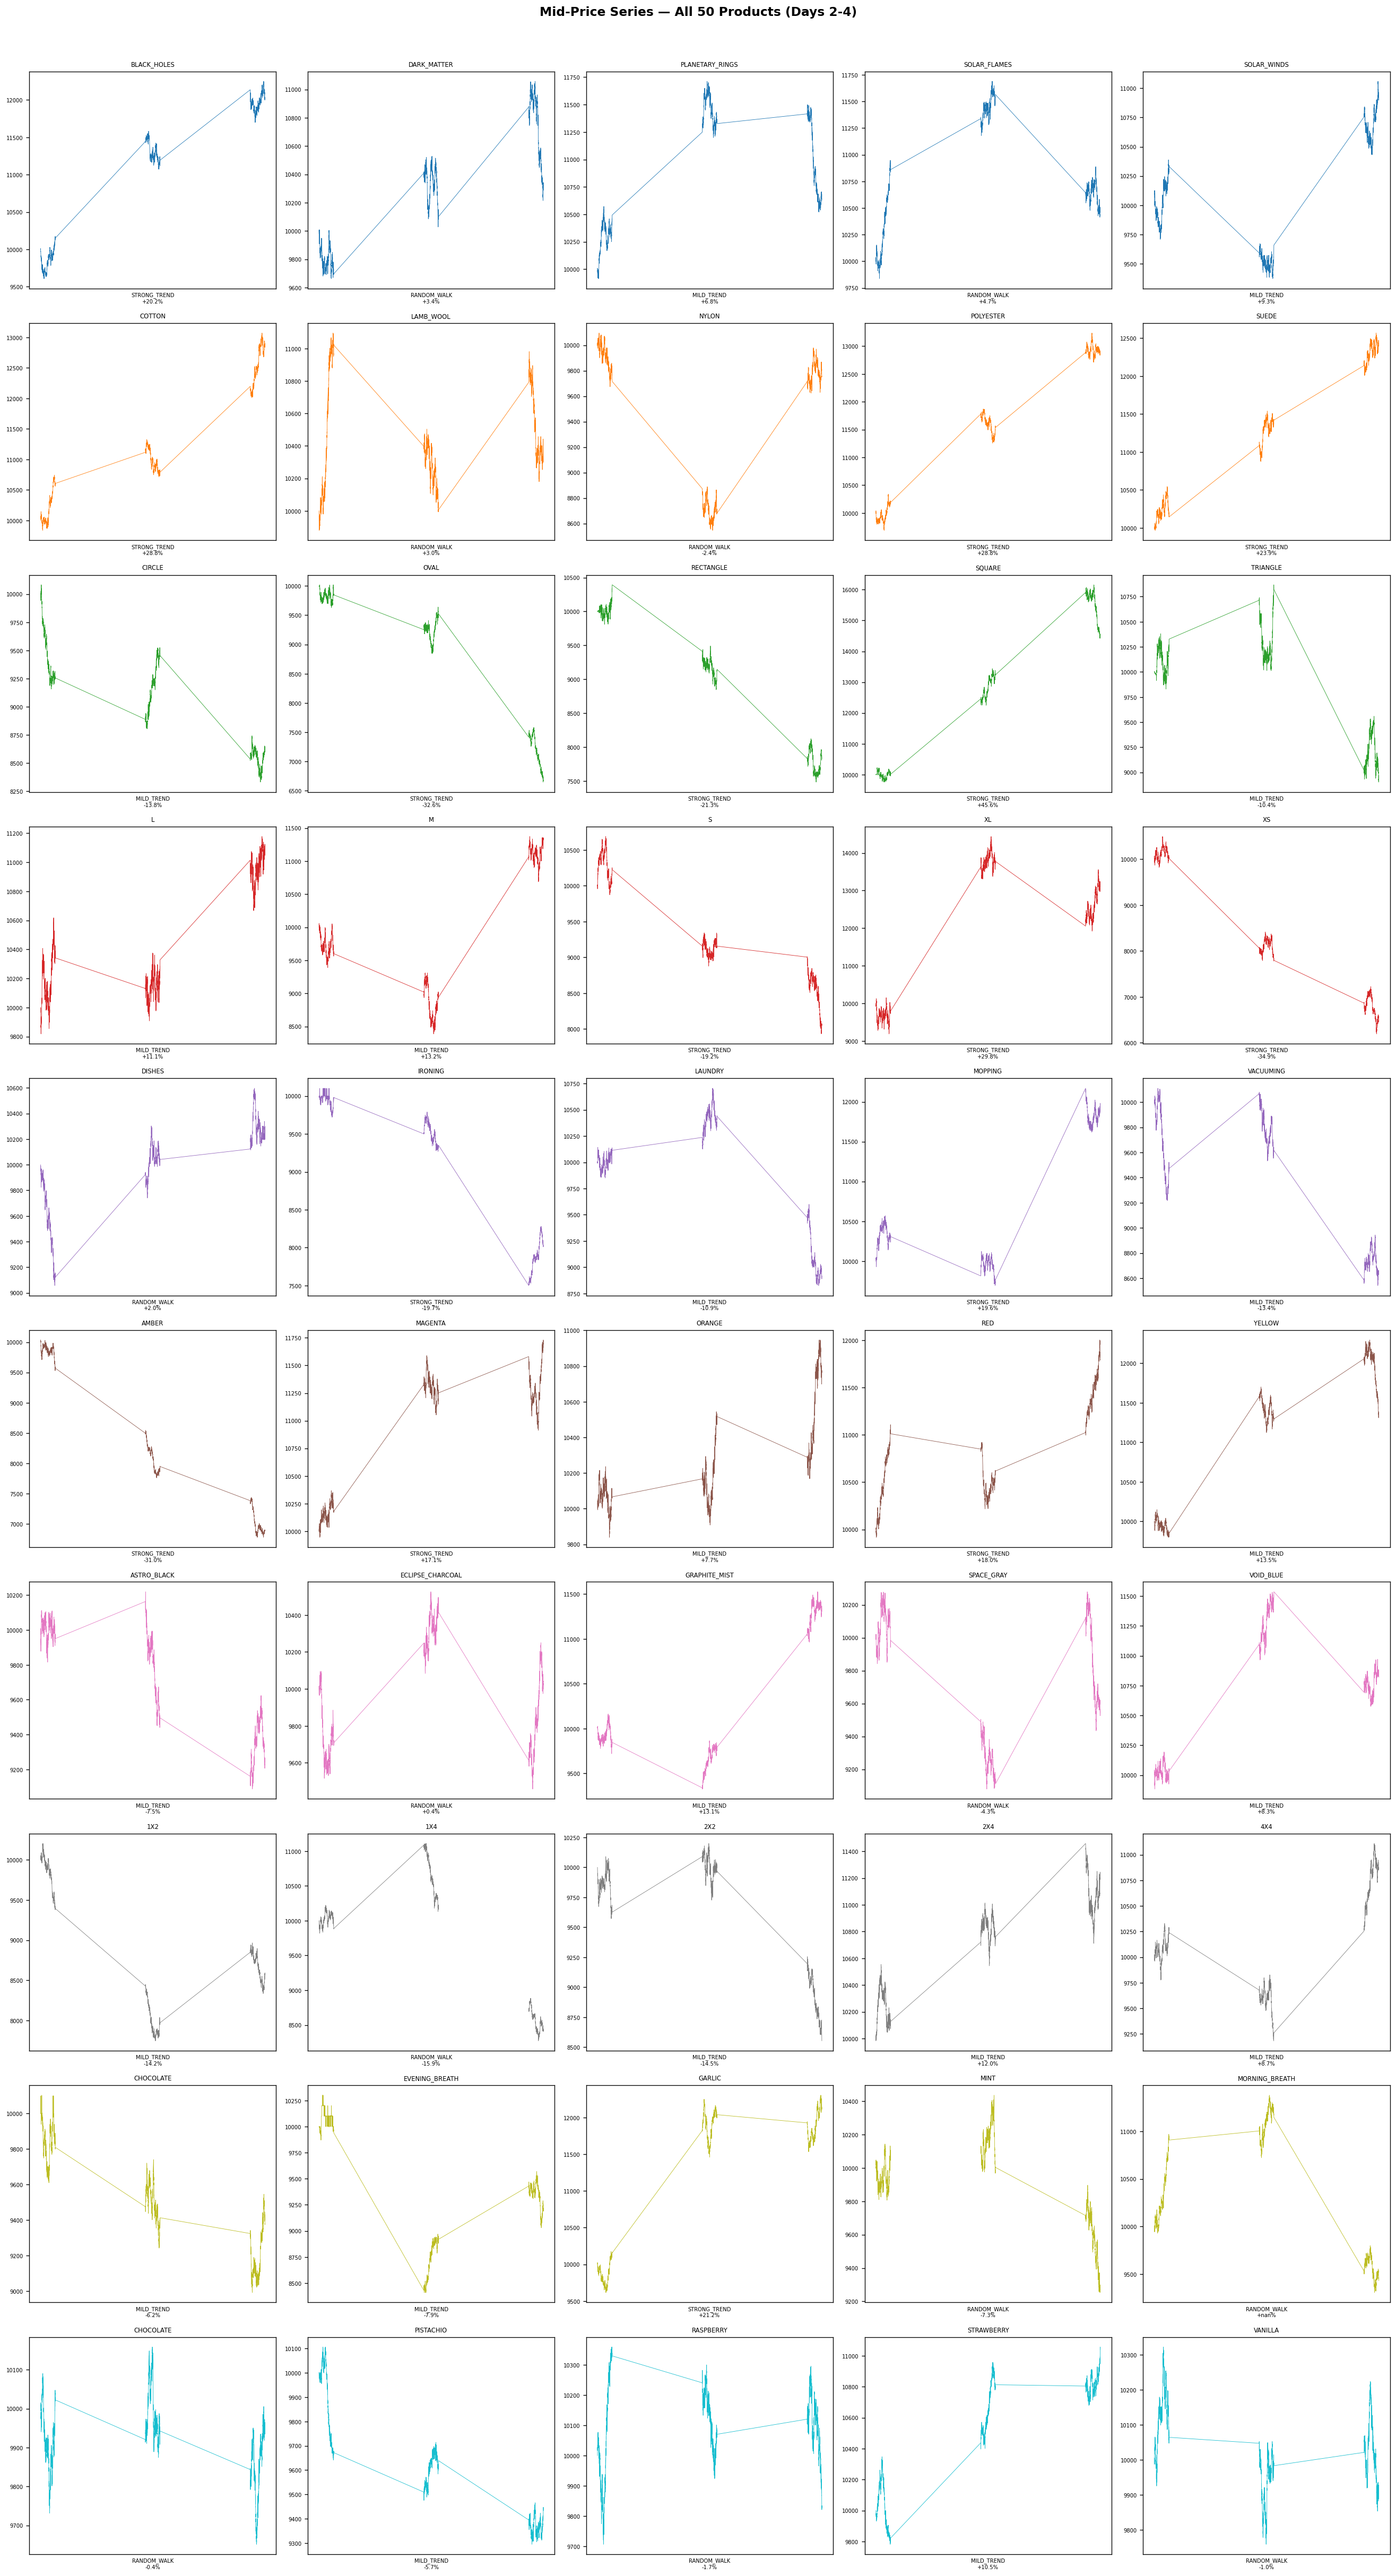

✅ Figure saved: price_action_all_products.png


In [5]:
# ─── CELL 5: Price Action Visualization ──────────────────────
fig, axes = plt.subplots(10, 5, figsize=(22, 40))
fig.suptitle("Mid-Price Series — All 50 Products (Days 2-4)", fontsize=14, fontweight='bold', y=1.01)

group_colors = {
    'GALAXY_SOUNDS': '#1f77b4', 'SLEEP_POD': '#ff7f0e', 'MICROCHIP': '#2ca02c',
    'PEBBLES': '#d62728',       'ROBOT': '#9467bd',     'UV_VISOR': '#8c564b',
    'TRANSLATOR': '#e377c2',    'PANEL': '#7f7f7f',     'OXYGEN_SHAKE': '#bcbd22',
    'SNACKPACK': '#17becf',
}

for i, (group, prods) in enumerate(GROUPS.items()):
    for j, prod in enumerate(sorted(prods)):
        ax = axes[i][j]
        sub = prices[prices['product']==prod].sort_values('global_ts')
        ax.plot(sub['global_ts'].values, sub['mid_price'].values,
                lw=0.5, color=group_colors[group])
        ax.set_title(prod.replace(group+'_',''), fontsize=7)
        ax.set_xticks([])
        regime = stats_df.loc[prod, 'regime']
        trend  = stats_df.loc[prod, 'total_trend_pct']
        ax.set_xlabel(f"{regime}\n{trend:+.1f}%", fontsize=6)
        ax.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig("price_action_all_products.png", bbox_inches='tight', dpi=100)
plt.show()
print("✅ Figure saved: price_action_all_products.png")

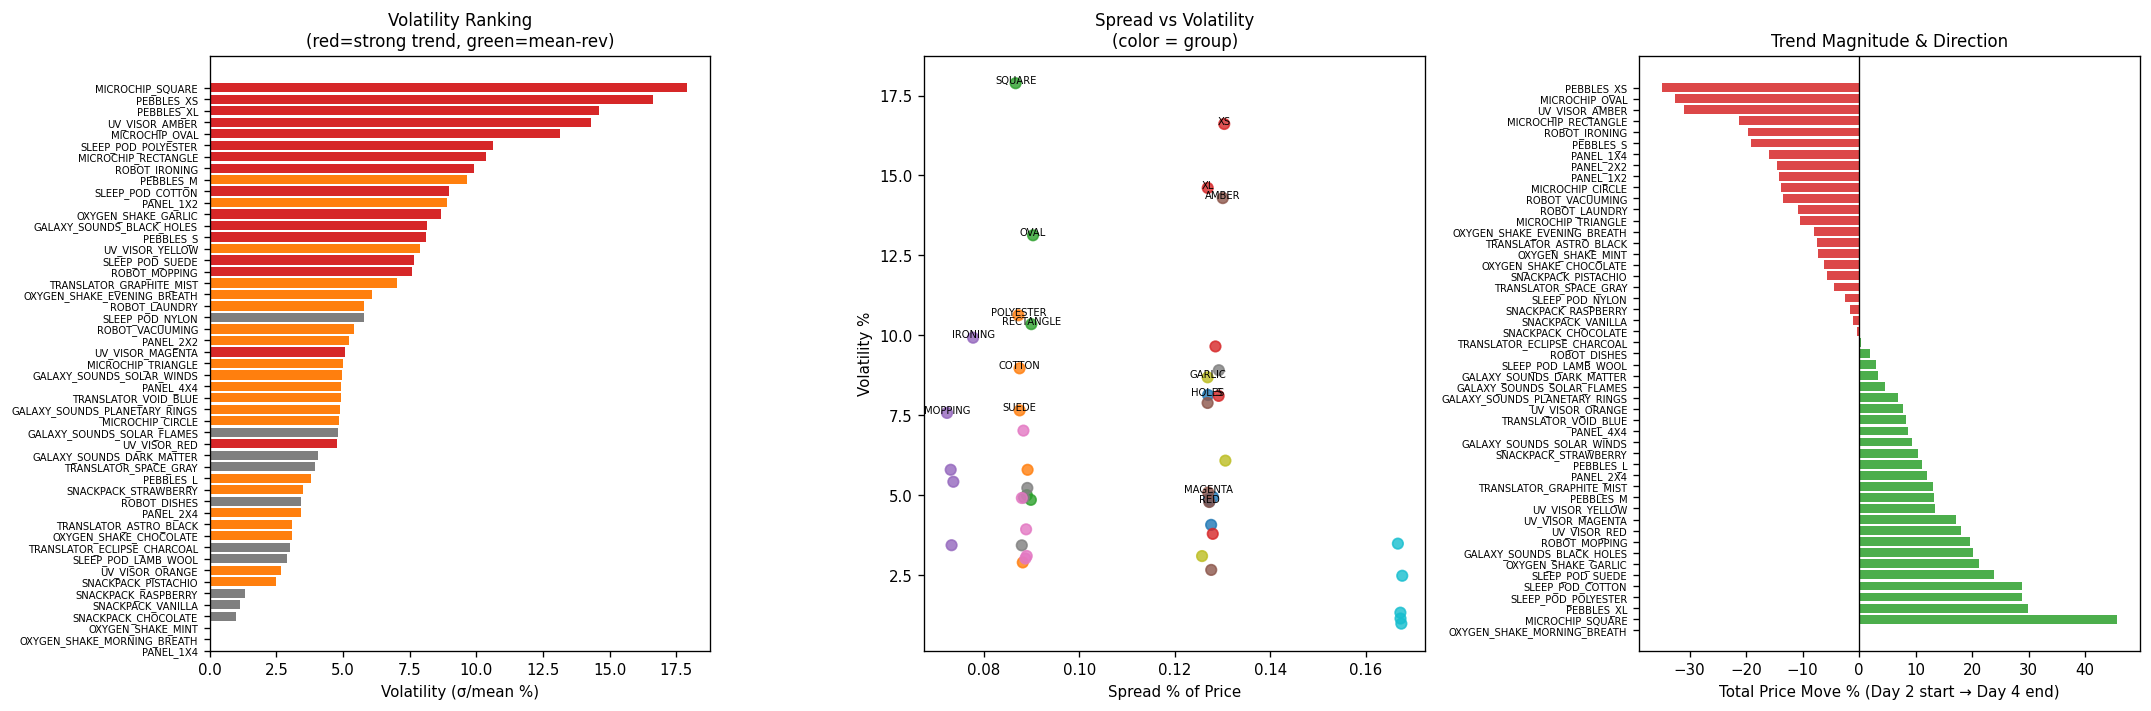

In [6]:
# ─── CELL 6: Volatility & Spread Analysis ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Volatility ranking
vol_sorted = stats_df['vol_pct'].sort_values(ascending=False)
colors = [{'STRONG_TREND':'#d62728','MILD_TREND':'#ff7f0e',
           'MEAN_REV_TIGHT':'#2ca02c','MEAN_REV':'#aec7e8',
           'RANDOM_WALK':'#7f7f7f'}[stats_df.loc[p,'regime']] for p in vol_sorted.index]
axes[0].barh(range(len(vol_sorted)), vol_sorted.values, color=colors)
axes[0].set_yticks(range(len(vol_sorted)))
axes[0].set_yticklabels(vol_sorted.index, fontsize=6)
axes[0].set_xlabel("Volatility (σ/mean %)")
axes[0].set_title("Volatility Ranking\n(red=strong trend, green=mean-rev)")
axes[0].invert_yaxis()

# 2. Spread vs Volatility scatter
scatter_colors = [group_colors[stats_df.loc[p,'group']] for p in stats_df.index]
axes[1].scatter(stats_df['spread_pct'], stats_df['vol_pct'], c=scatter_colors, s=40, alpha=0.8)
for prod in stats_df.index:
    if stats_df.loc[prod,'regime'] in ['STRONG_TREND']:
        axes[1].annotate(prod.split('_')[-1], (stats_df.loc[prod,'spread_pct'], stats_df.loc[prod,'vol_pct']),
                         fontsize=6, ha='center')
axes[1].set_xlabel("Spread % of Price")
axes[1].set_ylabel("Volatility %")
axes[1].set_title("Spread vs Volatility\n(color = group)")

# 3. Trend overview
trend_sorted = stats_df['total_trend_pct'].sort_values()
colors3 = ['#d62728' if v < 0 else '#2ca02c' for v in trend_sorted.values]
axes[2].barh(range(len(trend_sorted)), trend_sorted.values, color=colors3, alpha=0.85)
axes[2].set_yticks(range(len(trend_sorted)))
axes[2].set_yticklabels(trend_sorted.index, fontsize=6)
axes[2].set_xlabel("Total Price Move % (Day 2 start → Day 4 end)")
axes[2].set_title("Trend Magnitude & Direction")
axes[2].axvline(0, color='black', lw=0.8)
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig("volatility_spread_trend.png", bbox_inches='tight', dpi=100)
plt.show()
